# Interface and contact operations

This example starts with two tetrahedral parts that share a triangular interface. It finds the conforming interface, projects a slave point onto the lower part, and splits the mesh with a cohesive element. The rendered view highlights the shared facet and the point-to-facet projection.

In [1]:
import os
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv

import meshioplusplus as mp

pv.OFF_SCREEN = True

points = np.array([
    [0.0, 0.0, 0.0], [1.0, 0.0, 0.0], [0.0, 1.0, 0.0],
    [0.0, 0.0, 1.0], [0.0, 0.0, -1.0],
])
mesh = mp.Mesh(
    points,
    [("tetra", np.array([[0, 1, 2, 3], [0, 2, 1, 4]], dtype=np.int64))],
    regions=[
        mp.Region("upper", "cell", [0], dim=3),
        mp.Region("lower", "cell", [1], dim=3),
        mp.Region("slave", "point", [3]),
    ],
)

adjacent = mp.region_adjacency(mesh, ["upper", "lower"])
interface, report = mp.find_interface(
    mesh, "upper", "lower", return_report=True
)
contacts = mp.contact_pairs(mesh, "slave", "lower", tolerance=2.0)
split, split_report = mp.split_interface(
    mesh, report["side_a"], add_cohesive=True, return_report=True
)
print(f"shared facets: {len(adjacent.cells[0].data)}")
print(f"interface pairs: {report['num_pairs']}, area: {report['area']:.3f}")
print(f"slave-to-master gap: {contacts['gap'][0]:.3f}")
print(f"duplicated points: {split_report['num_duplicated_points']}, cohesive cells: {split_report['num_cohesive_cells']}")

shared facets: 1
interface pairs: 1, area: 0.500
slave-to-master gap: 0.000
duplicated points: 3, cohesive cells: 1


meshio warning [interfaces.cpp:820] region_adjacency: source Cell/Side regions are represented by the output adjacency regions; original entries are not copied


The gold triangle is the matched facet. The red marker is the slave point; the blue marker is its closest point on the lower part. If off-screen OpenGL is unavailable, the cell falls back to a Matplotlib 3-D rendering.

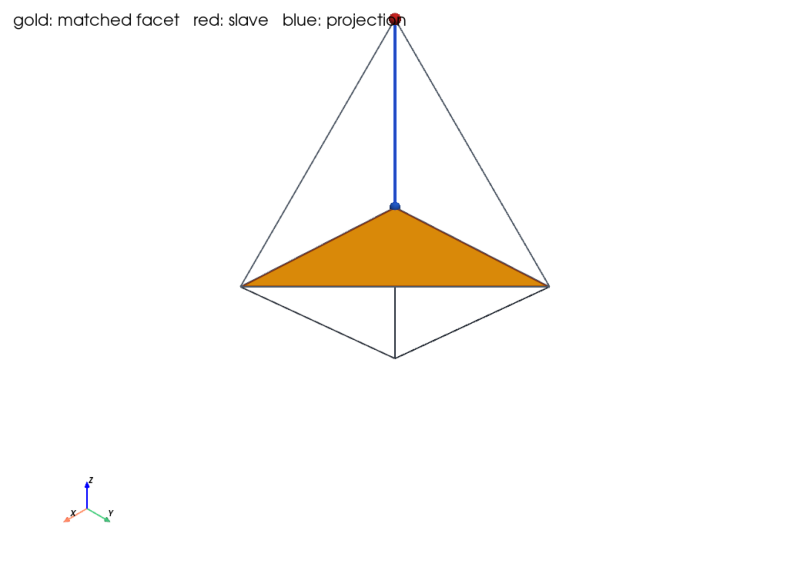

In [2]:
def pyvista_grid(mesh):
    with tempfile.NamedTemporaryFile(suffix=".vtu", delete=False) as f:
        path = f.name
    try:
        mp.write(path, mesh, compression=None)
        return pv.read(path)
    finally:
        os.unlink(path)


DOC_IMAGES = os.path.abspath(os.path.join(os.getcwd(), "..", "..", "doc", "public", "images"))

def fallback_plot():
    from mpl_toolkits.mplot3d.art3d import Poly3DCollection

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")
    faces = [[0, 1, 2], [0, 3, 1], [1, 3, 2], [2, 3, 0]]
    faces_b = [[0, 2, 1], [0, 1, 4], [1, 2, 4], [2, 0, 4]]
    for ids, color in ((faces, "#60a5fa"), (faces_b, "#34d399")):
        polys = [[points[i] for i in face] for face in ids]
        ax.add_collection3d(Poly3DCollection(polys, facecolor=color, alpha=0.16,
                                             edgecolor="#334155", linewidth=1.2))
    tri = points[interface.cells[0].data[0]]
    ax.add_collection3d(Poly3DCollection([tri], facecolor="#f59e0b", alpha=0.9,
                                         edgecolor="#7c2d12", linewidth=1.5))
    slave = points[3]
    closest = contacts["closest_point"][0]
    ax.scatter(*slave, color="#dc2626", s=50, label="slave point")
    ax.scatter(*closest, color="#2563eb", s=50, label="projection")
    ax.plot(*np.column_stack([slave, closest]), color="#1d4ed8", linestyle="--")
    ax.set(xlabel="x", ylabel="y", zlabel="z", title="Matched interface and contact projection")
    ax.legend(loc="upper left")
    ax.set_box_aspect((1, 1, 1.6))
    plt.tight_layout()
    os.makedirs(DOC_IMAGES, exist_ok=True)
    plt.savefig(os.path.join(DOC_IMAGES, "interface_contact.png"), dpi=120, bbox_inches="tight")
    plt.show()


try:
    grid = pyvista_grid(mesh)
    facets = pyvista_grid(interface)
    plotter = pv.Plotter(off_screen=True, window_size=(1000, 720))
    plotter.add_mesh(grid, style="wireframe", color="#64748b", line_width=2)
    plotter.add_mesh(facets, color="#f59e0b", show_edges=True, edge_color="#7c2d12", line_width=3)
    slave = points[3]
    closest = contacts["closest_point"][0]
    plotter.add_points(slave, color="#dc2626", point_size=16, render_points_as_spheres=True)
    plotter.add_points(closest, color="#2563eb", point_size=14, render_points_as_spheres=True)
    plotter.add_lines(np.vstack([slave, closest]), color="#1d4ed8", width=4)
    plotter.add_text("gold: matched facet   red: slave   blue: projection", font_size=12)
    plotter.camera_position = "iso"
    plotter.add_axes()
    image = plotter.screenshot(return_img=True)
    plotter.close()
    os.makedirs(DOC_IMAGES, exist_ok=True)
    plt.figure(figsize=(8, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.tight_layout()
    os.makedirs(DOC_IMAGES, exist_ok=True)
    plt.savefig(os.path.join(DOC_IMAGES, "interface_contact.png"), dpi=120, bbox_inches="tight")
    plt.show()
except Exception as exc:
    print("PyVista off-screen rendering unavailable; using Matplotlib fallback:", exc)
    fallback_plot()